#### Yuval Galula 206159345
#### Yarin Arava 207860206

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import fetch_openml
from sklearn.cluster import KMeans
from sklearn.mixture import GaussianMixture
from sklearn.metrics import accuracy_score

## Load data

In [2]:
# Load MNIST
mnist = fetch_openml('mnist_784', version=1, as_frame=False)

## Phase 1 - EDA

### Dataset Structure:

In [3]:
# Extract data and labels
X = mnist.data.astype(float) # (70000, 784)
X /= 255.0 # Normalize pixel values to [0, 1]
y = mnist.target.astype(int)

print("Number of samples:", X.shape[0])
print("Number of features for each sample:", X.shape[1])
print("Image resolution: ", np.sqrt(X.shape[1]).astype(int), "x", np.sqrt(X.shape[1]).astype(int))
print("Number of classes:", len(np.unique(y)))

# check if there are nan values in the dataset
print("**Number of NaN values in the dataset:", np.isnan(X).sum())

Number of samples: 70000
Number of features for each sample: 784
Image resolution:  28 x 28
Number of classes: 10
**Number of NaN values in the dataset: 0


We've loaded Digits MNIST using sklearn dataset, understanding that there are 70k samples, each sample has 784 features which is 28x28 flattened pixels.

**Next**, we'll take a visual check of the dataset using random indices.

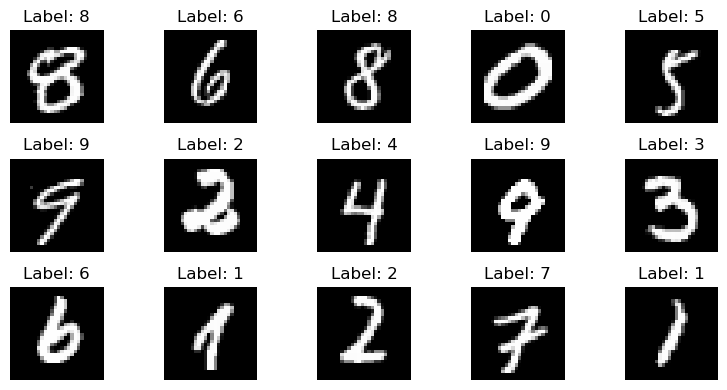

In [4]:
plt.figure(figsize=(8,4))

for i in range(15):
    plt.subplot(3, 5, i+1)
    idx = np.random.randint(0, len(X))
    plt.imshow(X[idx].reshape(28,28), cmap='gray')
    plt.title(f"Label: {y[idx]}")
    plt.axis('off')

plt.tight_layout()
plt.show()

### Labels Distribution:

In [5]:
unique, counts = np.unique(y, return_counts=True)

for digit, count in zip(unique, counts):
    print(f"Digit {digit}: {count} samples")

Digit 0: 6903 samples
Digit 1: 7877 samples
Digit 2: 6990 samples
Digit 3: 7141 samples
Digit 4: 6824 samples
Digit 5: 6313 samples
Digit 6: 6876 samples
Digit 7: 7293 samples
Digit 8: 6825 samples
Digit 9: 6958 samples


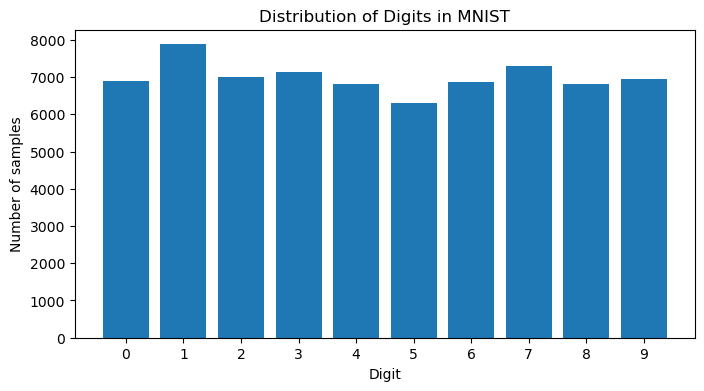

In [6]:
plt.figure(figsize=(8,4))

plt.bar(unique, counts)
plt.xlabel("Digit")
plt.ylabel("Number of samples")
plt.xticks(unique)

plt.title("Distribution of Digits in MNIST")
plt.show()

dataset seems to be balanced, furthermore, the digit '1' is the most frequent.


### Pixel Value Distribution

In [7]:
# Check the range of pixel values
print("Minimum pixel value:", X.min())
print("Maximum pixel value:", X.max())

Minimum pixel value: 0.0
Maximum pixel value: 1.0


In [8]:
# count the number of pixels with value 0, 255, and in between
num_zeros = np.sum(X == 0)
num_255 = np.sum(X == 255)
num_in_between = np.sum((X > 0) & (X < 255))
print("Number of pixels with value 0:", num_zeros)
print("Number of pixels with value 255:", num_255)
print("Number of pixels with value in between 0 and 255:", num_in_between)
print("total number of pixels:", X.size)

Number of pixels with value 0: 44374625
Number of pixels with value 255: 0
Number of pixels with value in between 0 and 255: 10505375
total number of pixels: 54880000


Display the count of the number of pixels with values **`0`**, **`255`**, **`0-255`**

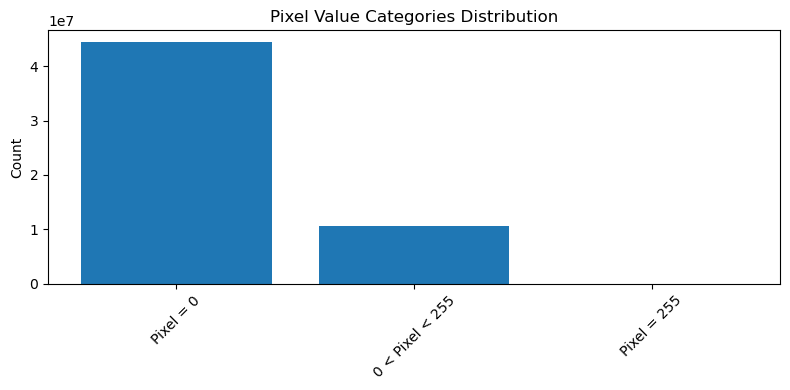

In [9]:
labels = ["Pixel = 0", "0 < Pixel < 255", "Pixel = 255"]
counts = [num_zeros, num_in_between ,num_255]

plt.figure(figsize=(8,4))

plt.bar(labels, counts)
plt.ylabel("Count")
plt.xticks(rotation=45)

plt.title("Pixel Value Categories Distribution")
plt.tight_layout()
plt.show()

Display the whole histogram

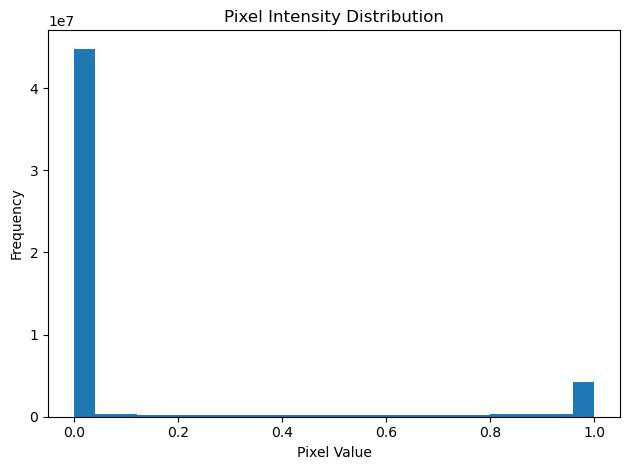

In [10]:
plt.hist(X.flatten(), bins=25)
plt.xlabel("Pixel Value")
plt.ylabel("Frequency")
plt.yticks

plt.title("Pixel Intensity Distribution")
plt.tight_layout()
plt.show()

as we can see, the majority of the images are black (background) pixels, right skewed to the brighter pixels which actually shows the details of the digits

### Mean Image Per Digit

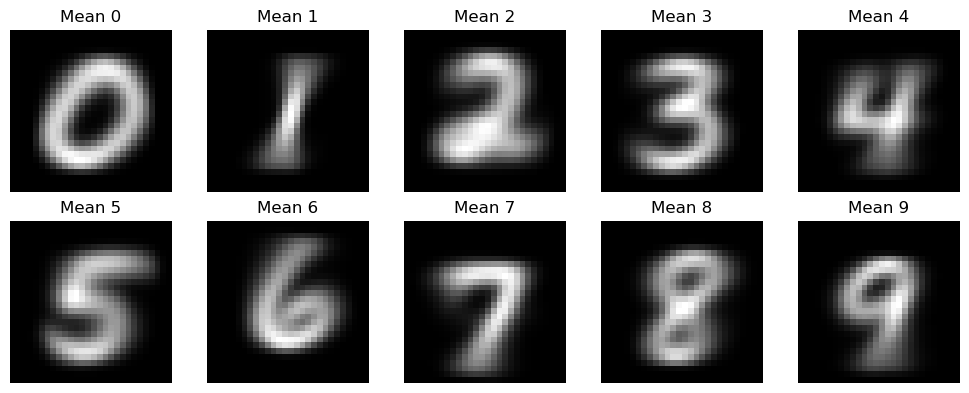

In [11]:
plt.figure(figsize=(10,4))

for digit in range(10):
    mean_digit = X[y == digit].mean(axis=0) # calculate mean pixel value for each digit class for each pixel position
    
    plt.subplot(2, 5, digit+1)
    plt.imshow(mean_digit.reshape(28,28), cmap='gray')
    plt.title(f"Mean {digit}")
    plt.axis('off')

plt.tight_layout()
plt.show()

Mean image per digit shows good and distinctive pattern of each digit, but remember that there are couple of stylish for couple of digits, therefore, they might seem similar.

## Phase 2 - Cluster numbers equal to the number of the labels

### Assistance Functions

In [12]:
# Clustering function
def fit_clustering(model, X):
    model.fit(X)
    # for KMeans
    if hasattr(model, "labels_"):
        clusters = model.labels_
    # for GMM
    else:
        clusters = model.predict(X)
        
    return clusters

In [13]:
# Majority voting function to map clusters to digits
def map_clusters_to_digits(clusters, y, n_clusters=10):
    cluster_to_digit = {}
    
    for cluster_id in range(n_clusters):
        # Get true labels of samples inside cluster
        labels_in_cluster = y[clusters == cluster_id]

        # Find the most common label in this cluster
        most_common = np.bincount(labels_in_cluster).argmax()
        
        cluster_to_digit[cluster_id] = most_common
        
    return cluster_to_digit

In [14]:
# For each Cluster change all the assignments to representative digit
def predict_labels_from_clusters(clusters, cluster_to_digit):
    # contain the predicted labels for each sample based on their cluster assignment
    y_pred = np.zeros_like(clusters)
    
    for cluster_id, digit in cluster_to_digit.items():
        y_pred[clusters == cluster_id] = digit
        
    return y_pred

In [15]:
# plot bar chart of digit distribution across clusters
def barPlot_digit_cluster_distribution(clusters, y, title):

    plt.figure(figsize=(15,10))

    for digit in range(10):
        
        digit_clusters = clusters[y == digit]
        unique, counts = np.unique(digit_clusters, return_counts=True)
        
        # Create full 0-9 vector
        cluster_counts = np.zeros(10)
        cluster_counts[unique] = counts
        
        plt.subplot(2,5,digit+1)
        plt.bar(range(10), cluster_counts)
        plt.title(f"Digit {digit}")
        plt.xlabel("Cluster")
        plt.ylabel("Count")
        plt.xticks(range(10))

    plt.tight_layout()
    plt.show()


In [16]:
# plot heatmap of digit distribution across clusters
def plot_digit_cluster_distribution(clusters, y, n_clusters=10, title=""):
    
    digit_cluster_matrix = np.zeros((10, n_clusters))
    
    for digit in range(10):
        # get cluster positions for samples of this digit
        digit_clusters = clusters[y == digit]
        
        # count how many samples of this digit fall into each cluster
        unique, counts = np.unique(digit_clusters, return_counts=True)
        
        digit_cluster_matrix[digit, unique] = counts

    plt.figure(figsize=(20,5))
    sns.heatmap(digit_cluster_matrix, cmap="Blues", xticklabels=range(n_clusters), yticklabels=range(10))
    plt.yticks(rotation=0)
    
    plt.xlabel("Cluster")
    plt.ylabel("True Digit")
    plt.title(title)
    plt.show()

In [17]:
# visualize cluster centers and random samples from each cluster
def visualize_clusters(X, clusters, model, cluster_to_digit, samples_per_cluster=5):
    
    if hasattr(model, "cluster_centers_"):
        # for KMeans
        means = model.cluster_centers_
    else:
        # for GMM
        means = model.means_
    
    n_clusters = means.shape[0]
    
    plt.figure(figsize=(12, 2 * n_clusters))
    
    for cluster_id in range(n_clusters):
        
        # Mean image
        plt.subplot(n_clusters, samples_per_cluster + 1, cluster_id*(samples_per_cluster+1) + 1)
        plt.imshow(means[cluster_id].reshape(28,28), cmap='gray')
        plt.title(f"Cluster: {cluster_id} \n Represented digit: {cluster_to_digit[cluster_id]}")
        plt.axis('off')
        
        # Random samples
        cluster_indices = np.where(clusters == cluster_id)[0]
        random_samples = np.random.choice(cluster_indices, samples_per_cluster, replace=False)
        
        for i, idx in enumerate(random_samples):
            plt.subplot(n_clusters, samples_per_cluster + 1, cluster_id*(samples_per_cluster+1) + 2 + i)
            plt.imshow(X[idx].reshape(28,28), cmap='gray')
            plt.axis('off')

    plt.tight_layout()
    plt.show()

### KMeans Model Run

In [18]:
# KMeans Clustering
kmeans = KMeans(n_clusters=10, random_state=42)

clusters_kmeans = fit_clustering(kmeans, X)

print("Clustering using KMeans completed.")

Clustering using KMeans completed.


In [19]:
# Map clusters to digits using majority voting
mapping_kmeans = map_clusters_to_digits(clusters_kmeans, y)

print("Cluster → Digit mapping:")
for cluster_id, digit in mapping_kmeans.items():
    print(f"Cluster {cluster_id} →  Most Common Digit {digit}")

Cluster → Digit mapping:
Cluster 0 →  Most Common Digit 4
Cluster 1 →  Most Common Digit 1
Cluster 2 →  Most Common Digit 1
Cluster 3 →  Most Common Digit 3
Cluster 4 →  Most Common Digit 0
Cluster 5 →  Most Common Digit 9
Cluster 6 →  Most Common Digit 7
Cluster 7 →  Most Common Digit 2
Cluster 8 →  Most Common Digit 6
Cluster 9 →  Most Common Digit 8


In [20]:
# Predict labels based on cluster assignments and mapping
y_pred_kmeans = predict_labels_from_clusters(clusters_kmeans, mapping_kmeans)

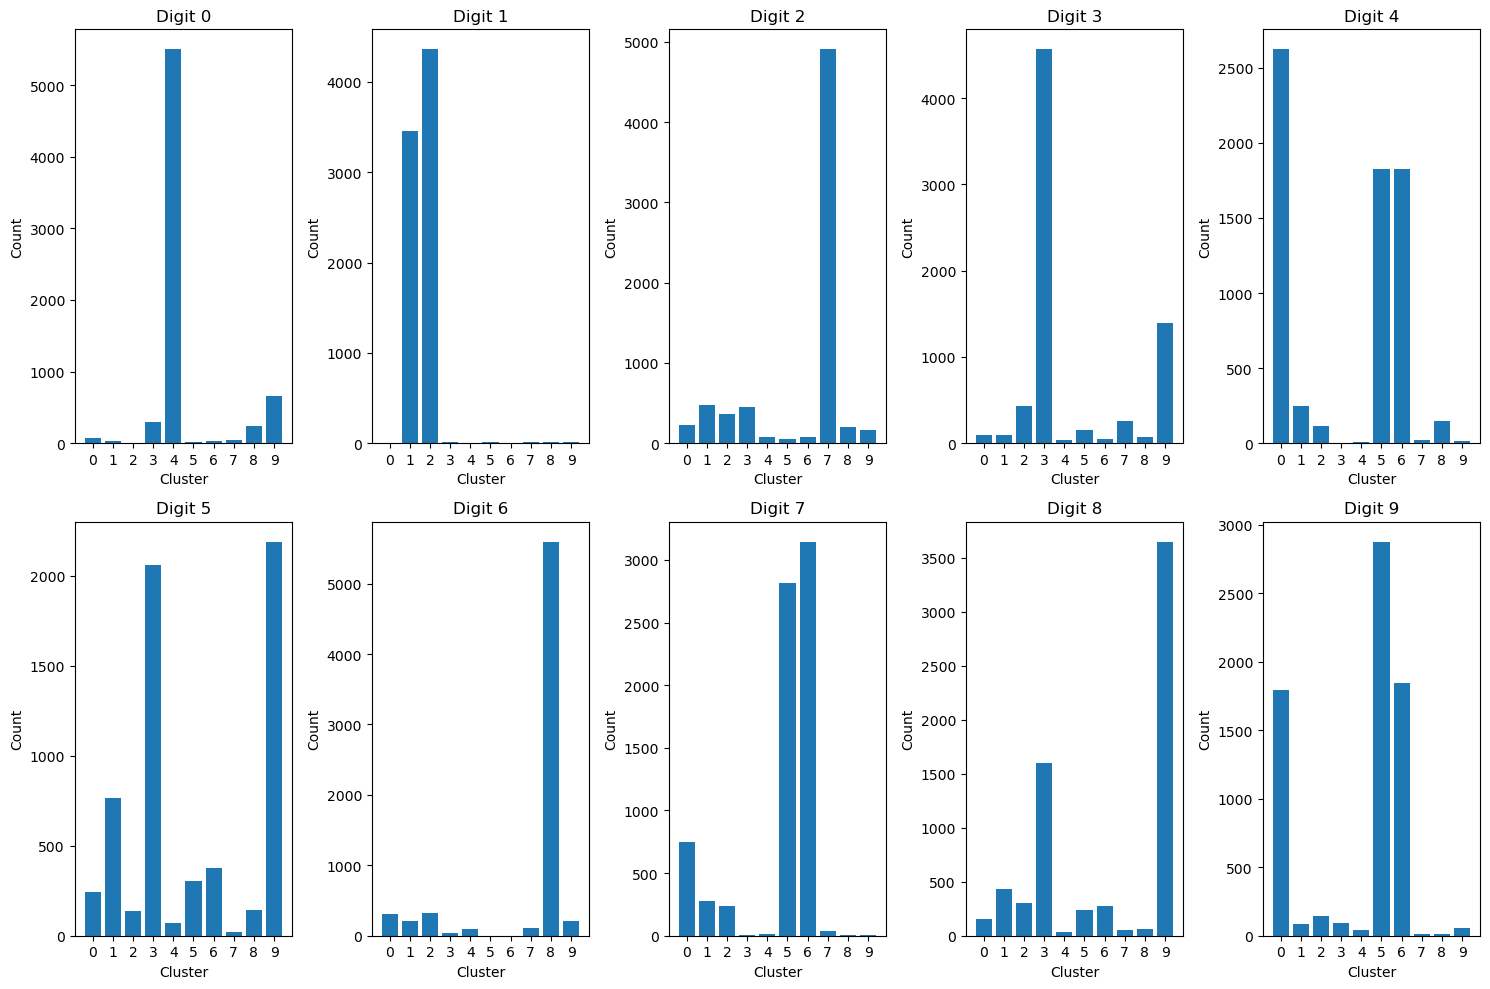

In [21]:
# plot bar chart of digit distribution across clusters
barPlot_digit_cluster_distribution(clusters_kmeans, y, title="Digit Distribution - KMeans")

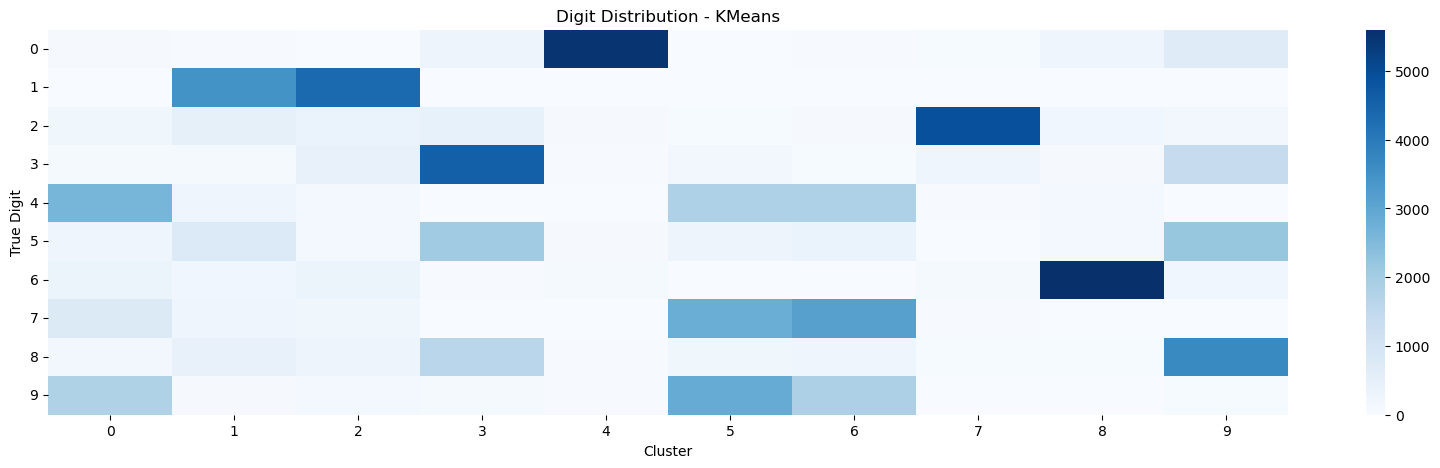

In [22]:
# plot heatmap of digit distribution across clusters
plot_digit_cluster_distribution(clusters_kmeans, y, title="Digit Distribution - KMeans")

Explanation of the heatmap:

for each row (represented digit), the less columns that are darker => the better the digit is recognized. for example, digit 0 represented by Cluster 4, all other columns for that row has bright (low) samples inside them. Digit 9 is represented in clusters 0,5,6 => cluster 0 also recognize digit 4, clusters 5 and 6 also recognize digits 4 & 7.

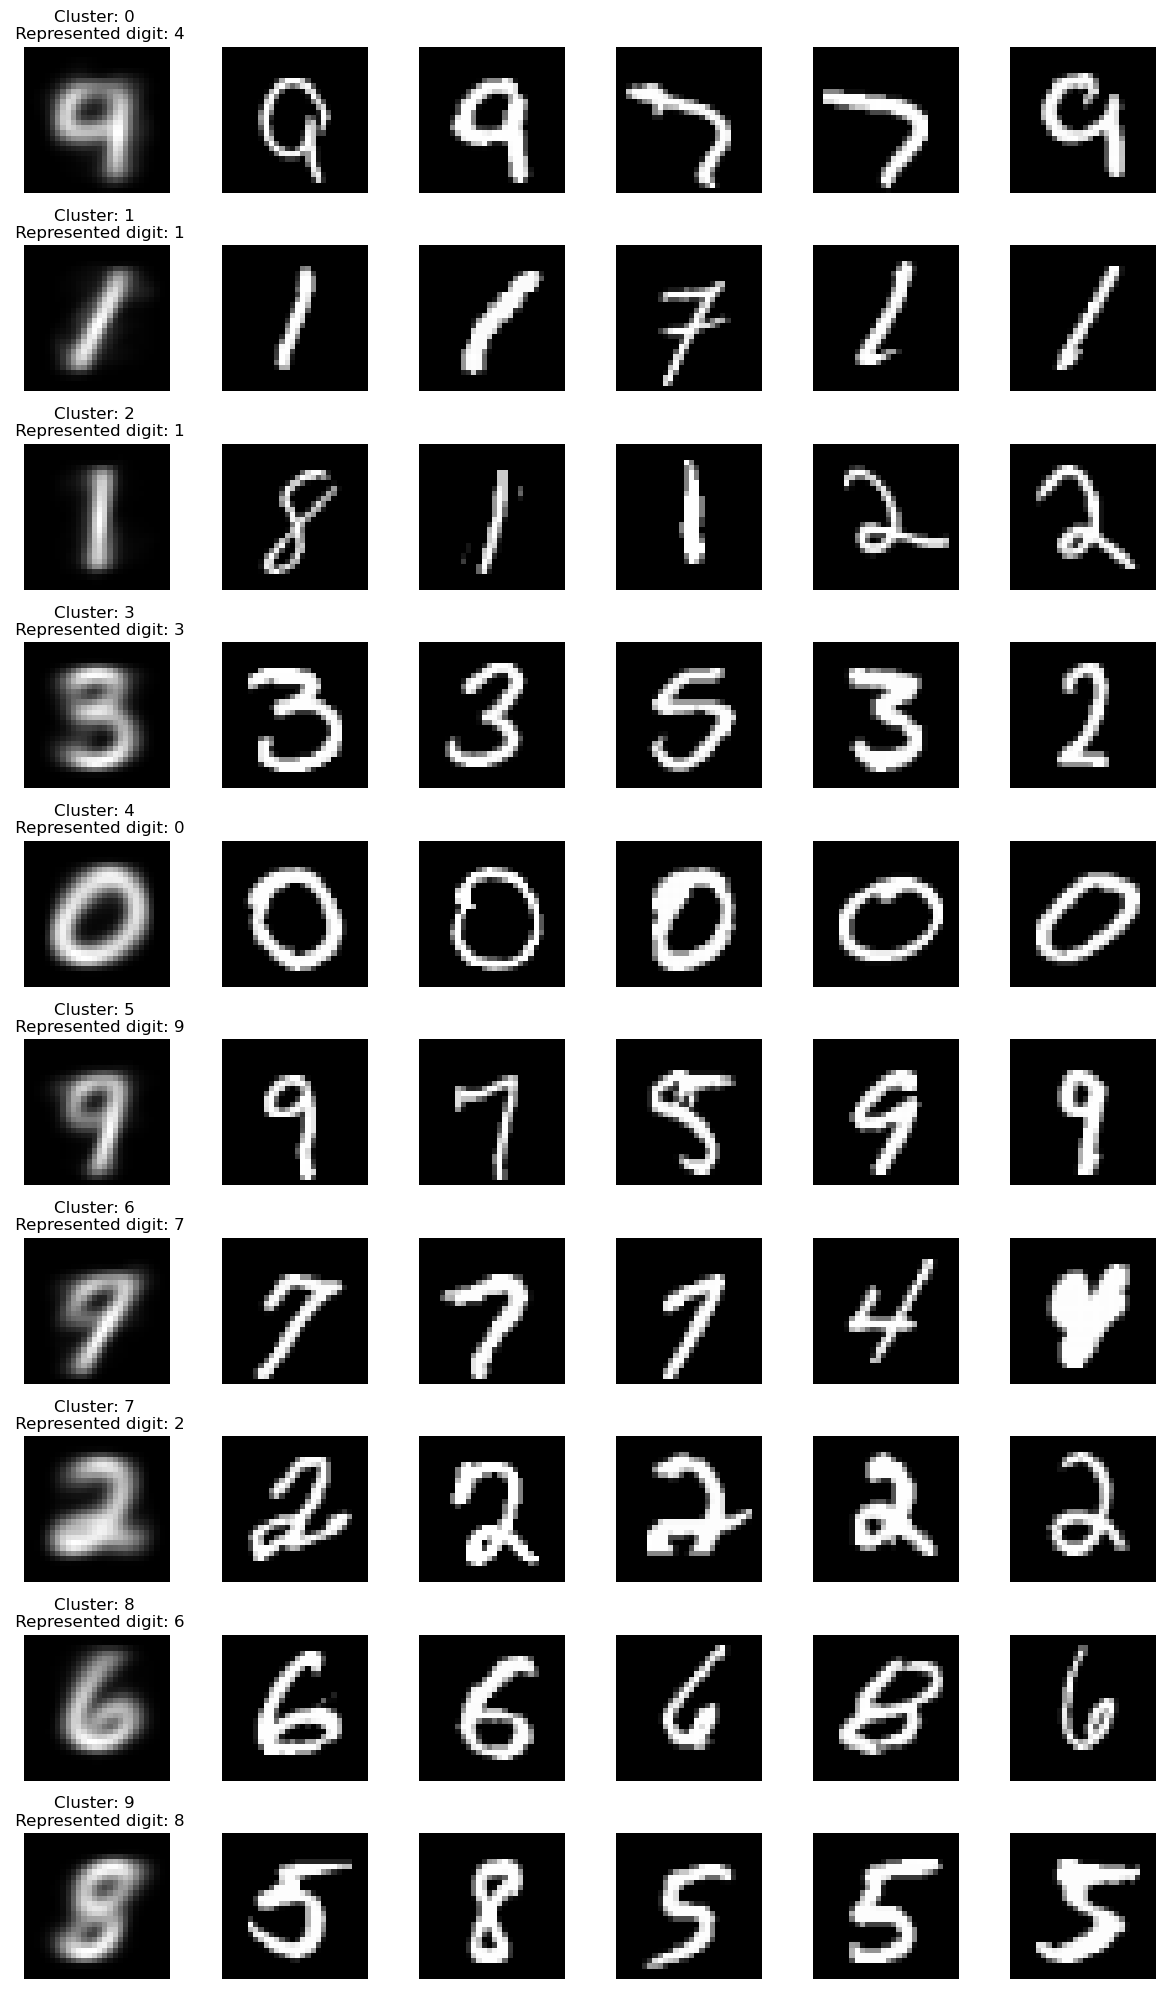

In [23]:
# show cluster centers and random samples from each cluster
visualize_clusters(X, clusters_kmeans, kmeans, mapping_kmeans)

### GMM Model Run - Full Type

In [24]:
# Gaussian Mixture Model Clustering
gmm_full = GaussianMixture(n_components=10, covariance_type='full', random_state=42)
clusters_gmm_full = fit_clustering(gmm_full, X)

print("Clustering using GMM (Full Covariance) completed.")

Clustering using GMM (Full Covariance) completed.


In [25]:
# Map clusters to digits using majority voting
mapping_gmm_full = map_clusters_to_digits(clusters_gmm_full, y)

print("Cluster → Digit mapping:")
for cluster_id, digit in mapping_gmm_full.items():
    print(f"Cluster {cluster_id} →  Most Common Digit {digit}")

Cluster → Digit mapping:
Cluster 0 →  Most Common Digit 9
Cluster 1 →  Most Common Digit 1
Cluster 2 →  Most Common Digit 1
Cluster 3 →  Most Common Digit 3
Cluster 4 →  Most Common Digit 0
Cluster 5 →  Most Common Digit 9
Cluster 6 →  Most Common Digit 7
Cluster 7 →  Most Common Digit 2
Cluster 8 →  Most Common Digit 6
Cluster 9 →  Most Common Digit 5


In [26]:
# Predict labels based on cluster assignments and mapping
y_pred_gmm_full = predict_labels_from_clusters(clusters_gmm_full, mapping_gmm_full)

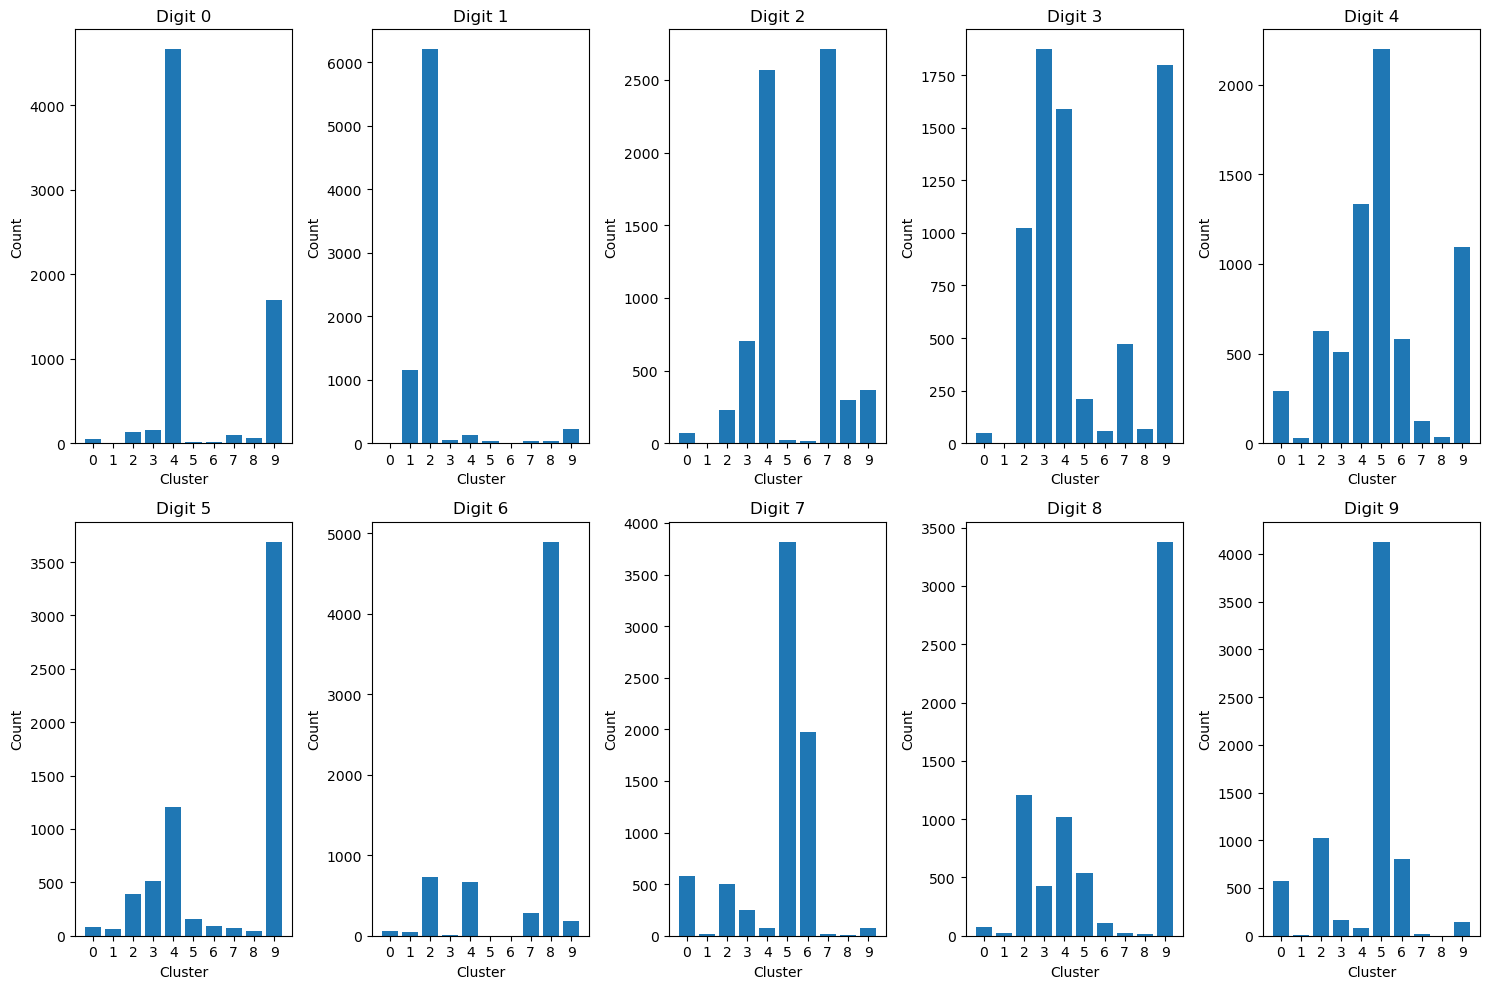

In [27]:
# plot bar chart of digit distribution across clusters
barPlot_digit_cluster_distribution(clusters_gmm_full, y, title="Digit Distribution - GMM (Full Covariance)")

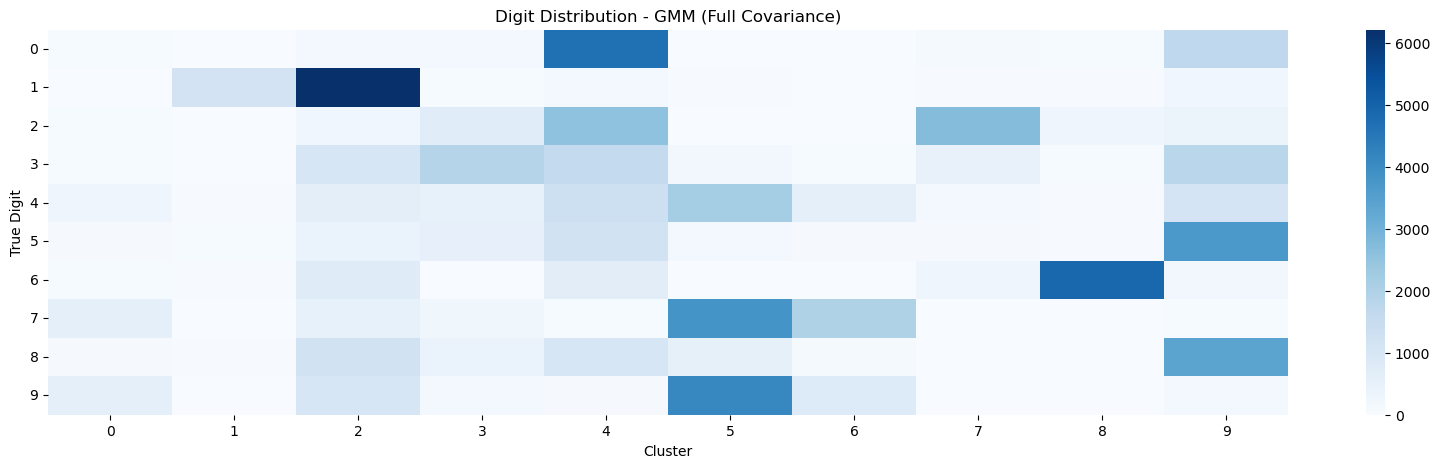

In [28]:
# plot heatmap of digit distribution across clusters
plot_digit_cluster_distribution(clusters_gmm_full, y, title="Digit Distribution - GMM (Full Covariance)")

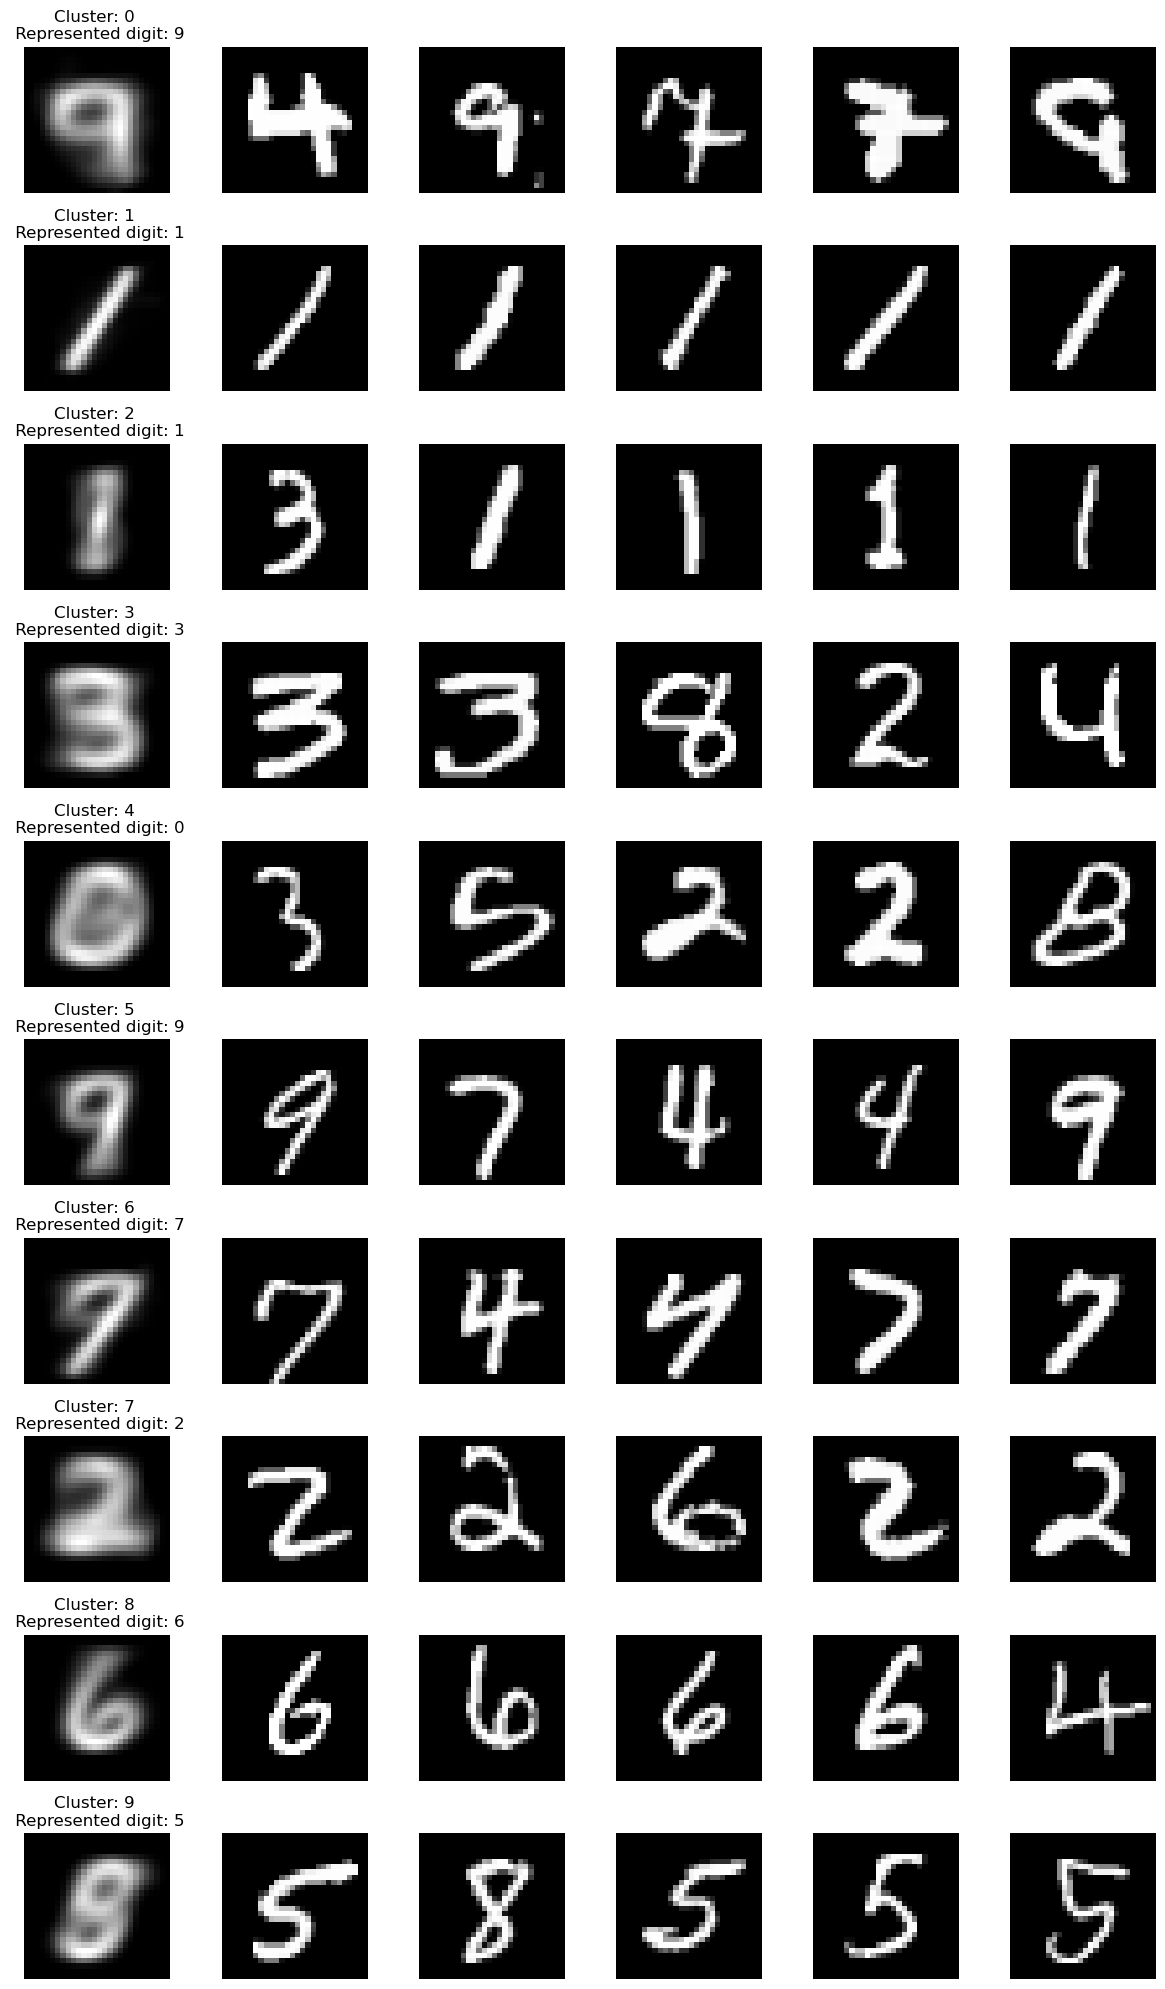

In [29]:
# show cluster centers and random samples from each cluster
visualize_clusters(X, clusters_gmm_full, gmm_full, mapping_gmm_full)

### GMM Model Run - Diag Type

In [30]:
# Gaussian Mixture Model with Diagonal Covariance
gmm_diag = GaussianMixture(n_components=10, covariance_type='diag', random_state=42)

clusters_gmm_diag = fit_clustering(gmm_diag, X)

print("Clustering using GMM (Diagonal Covariance) completed.")

Clustering using GMM (Diagonal Covariance) completed.


In [31]:
# Map clusters to digits using majority voting
mapping_gmm_diag = map_clusters_to_digits(clusters_gmm_diag, y)

print("Cluster → Digit mapping:")
for cluster_id, digit in mapping_gmm_diag.items():
    print(f"Cluster {cluster_id} →  Most Common Digit {digit}")

Cluster → Digit mapping:
Cluster 0 →  Most Common Digit 9
Cluster 1 →  Most Common Digit 8
Cluster 2 →  Most Common Digit 1
Cluster 3 →  Most Common Digit 3
Cluster 4 →  Most Common Digit 0
Cluster 5 →  Most Common Digit 7
Cluster 6 →  Most Common Digit 7
Cluster 7 →  Most Common Digit 2
Cluster 8 →  Most Common Digit 6
Cluster 9 →  Most Common Digit 5


In [32]:
# Predict labels based on cluster assignments and mapping
y_pred_gmm_diag = predict_labels_from_clusters(clusters_gmm_diag, mapping_gmm_diag)

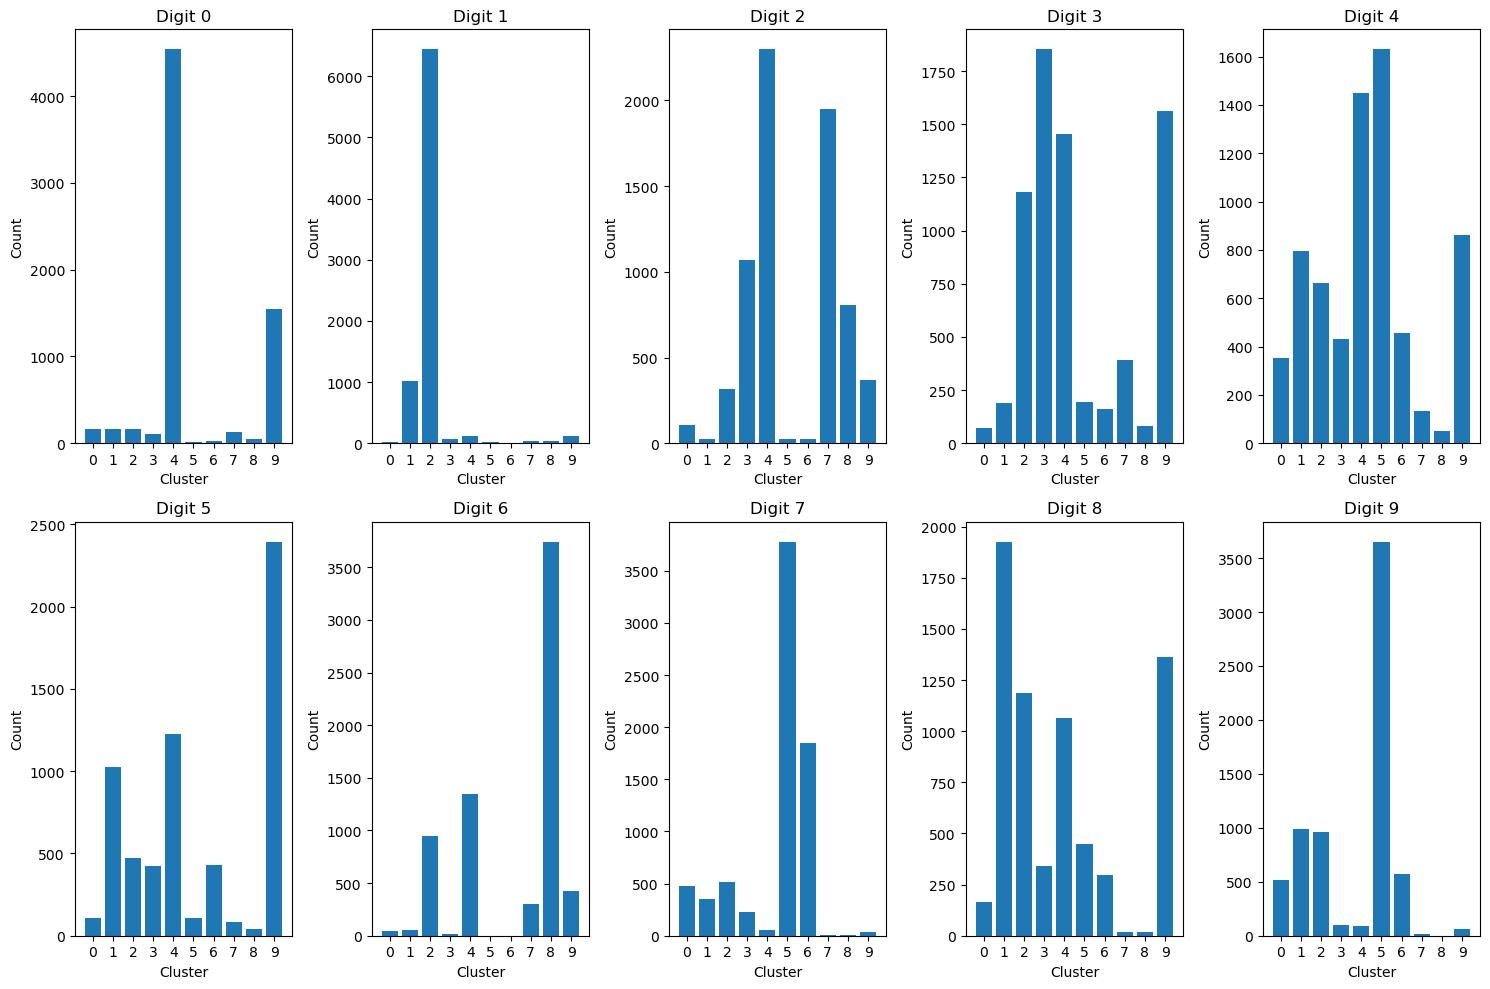

In [33]:
# plot bar chart of digit distribution across clusters
barPlot_digit_cluster_distribution(clusters_gmm_diag, y, title="Digit Distribution - GMM (Diagonal Covariance)")

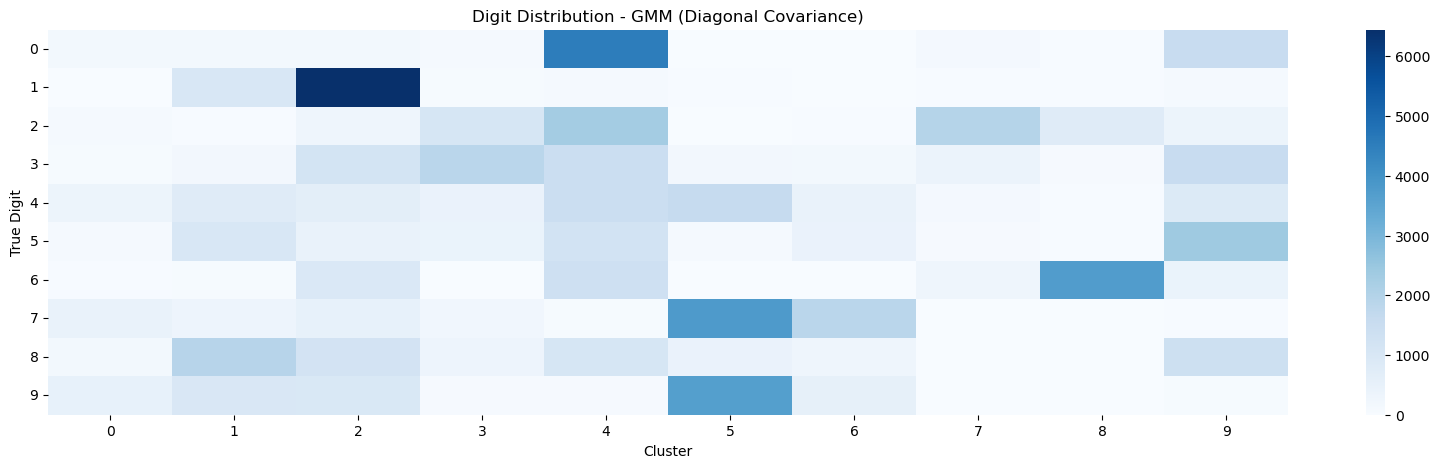

In [34]:
# plot heatmap of digit distribution across clusters
plot_digit_cluster_distribution(clusters_gmm_diag, y, title="Digit Distribution - GMM (Diagonal Covariance)")

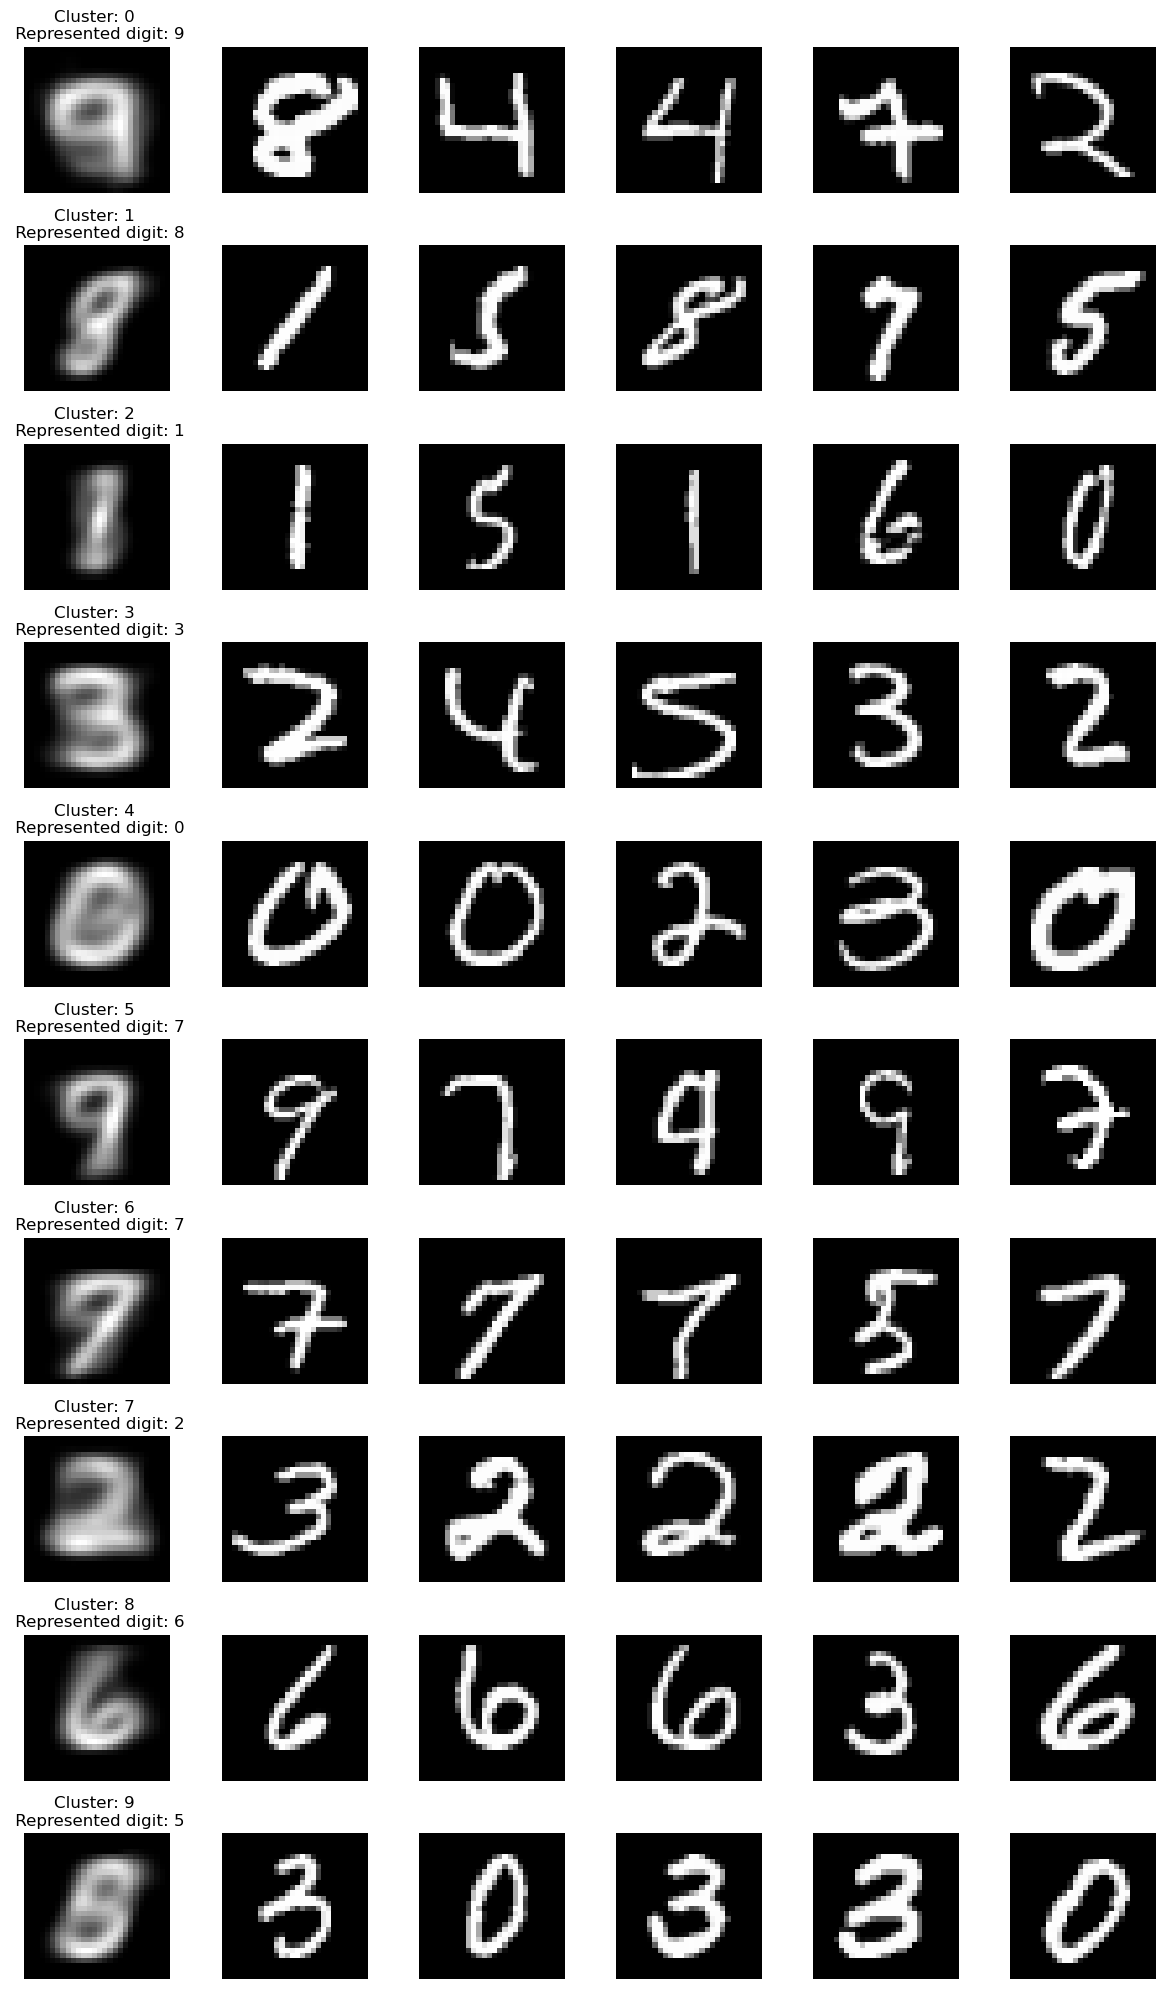

In [35]:
# show cluster centers and random samples from each cluster
visualize_clusters(X, clusters_gmm_diag, gmm_diag, mapping_gmm_diag)

### Conclusions & Insights

Both **Full** and **Diag** seems to have same behavior on the data, both represent same digit on 2 different clusters. The mean image of the clusters show same visual coherent, also the runtime of **Full** cost around 10 min, while the **Diag** took ~10 sec (like KMeans).

We also decided to check accuracies.

In [36]:
# Evaluate clustering performance using accuracy score
accuracy_kmeans = accuracy_score(y, y_pred_kmeans)
accuracy_gmm_full = accuracy_score(y, y_pred_gmm_full)
accuracy_gmm_diag = accuracy_score(y, y_pred_gmm_diag)

print(f"KMeans Accuracy: {accuracy_kmeans:.4f}")
print(f"GMM (Full Covariance) Accuracy: {accuracy_gmm_full:.4f}")
print(f"GMM (Diagonal Covariance) Accuracy: {accuracy_gmm_diag:.4f}")

KMeans Accuracy: 0.5815
GMM (Full Covariance) Accuracy: 0.4554
GMM (Diagonal Covariance) Accuracy: 0.4143


Full type provides a slightly better probabilistic fit than the Diag type.

Shared Results:
- Fail to perfectly isolate each digit into a single cluster.
- Split some digits across multiple clusters.
- Mix visually similar digits like 3 & 5 , 1 & 7..

Different Results:
- **Runtime**: while KMeans and Diag type took ~10 sec, the Full type ran for ~10 min.
- KMeans has better mean cluster image.
- Based on the heatmaps, seems that the digits on KMeans are seperated between 1-2 strong and dominant clusters, while the digits on GMM are seperated between 1-4 clusters and the dominant cluster they tagged to is less decisive than the KMean's.

## Phase 3 - Cluster numbers higher than the number of the labels

### Assistance Functions - KMeans different K's

In [37]:
# init kArray and results dictionary to store clustering results for different K values
kArray = [10, 20, 30, 50, 100]
results = {}

for K in kArray:
    
    print(f"\nRunning KMeans with K={K}")
    
    model = KMeans(n_clusters=K, random_state=42)
    
    clusters = fit_clustering(model, X) # fit KMeans
    
    mapping = map_clusters_to_digits(clusters, y, K) # map clusters to digits using majority voting
    
    y_pred = predict_labels_from_clusters(clusters, mapping) # predict labels based on cluster assignments and mapping
    
    acc = accuracy_score(y, y_pred) # calculate accuracy
    
    results[K] = {
        "model": model,
        "clusters": clusters,
        "mapping": mapping,
        "accuracy": acc
    }

print(f"results Initialized with K values: {kArray}")


Running KMeans with K=10

Running KMeans with K=20

Running KMeans with K=30

Running KMeans with K=50

Running KMeans with K=100
results Initialized with K values: [10, 20, 30, 50, 100]


In [38]:
# Plot size of each cluster for different K values
def plot_cluster_sizes(clusters, K):
    sizes = [np.sum(clusters == k) for k in range(K)]
    
    plt.figure(figsize=(6,4))
    plt.bar(range(K), sizes)

    plt.xlabel("Cluster")
    plt.ylabel("Number of Samples")
    plt.title(f"Cluster Sizes (K={K})")
    plt.show()

In [39]:
# Function to Show cluster means and samples for clusters where the given digit is dominant
def inspect_digit_clusters(digit, results, X, y, Ks, samples_per_cluster=4, dominance_threshold=0.5):
    """
    digit: digit to analyze (0-9)
    results: dictionary storing model, clusters per K
    X: dataset
    y: true labels
    Ks: list of K values to compare
    dominance_threshold: minimum % of digit in cluster
    """
    for K in Ks:
        
        model = results[K]["model"]
        clusters = results[K]["clusters"]
        
        if hasattr(model, "cluster_centers_"):
            means = model.cluster_centers_
        else:
            means = model.means_
        
        print(f"\n========== K = {K} ==========")
        
        cluster_ids = np.unique(clusters)
        
        for cluster_id in cluster_ids:
            
            indices = np.where(clusters == cluster_id)[0]
            if len(indices) == 0:
                continue
            
            labels = y[indices]
            digit_ratio = np.sum(labels == digit) / len(labels)
            
            # Only show clusters where digit dominates
            if digit_ratio >= dominance_threshold:
                
                print(f"Cluster {cluster_id} | size={len(indices)} | purity={digit_ratio:.2f}")
                
                plt.figure(figsize=(10,2))
                
                # Mean image
                plt.subplot(1, samples_per_cluster+1, 1)
                plt.imshow(means[cluster_id].reshape(28,28), cmap='gray')
                plt.title(f"Mean\nPurity:{digit_ratio:.2f}")
                plt.axis('off')
                
                # Random samples
                sample_indices = np.random.choice(indices, min(samples_per_cluster, len(indices)), replace=False)
                
                for i, idx in enumerate(sample_indices):
                    plt.subplot(1, samples_per_cluster+1, i+2)
                    plt.imshow(X[idx].reshape(28,28), cmap='gray')
                    plt.axis('off')
                
                plt.suptitle(f"Digit {digit} | Cluster {cluster_id} | K={K}")
                plt.show()

### KMeans Model Run - K's in [10, 20, 30, 50, 100]

In [40]:
# Print accuracy for each K
for K in kArray:
    print(f"K={K} | Accuracy: {results[K]['accuracy']:.4f}")

K=10 | Accuracy: 0.5815
K=20 | Accuracy: 0.7183
K=30 | Accuracy: 0.7592
K=50 | Accuracy: 0.8000
K=100 | Accuracy: 0.8689


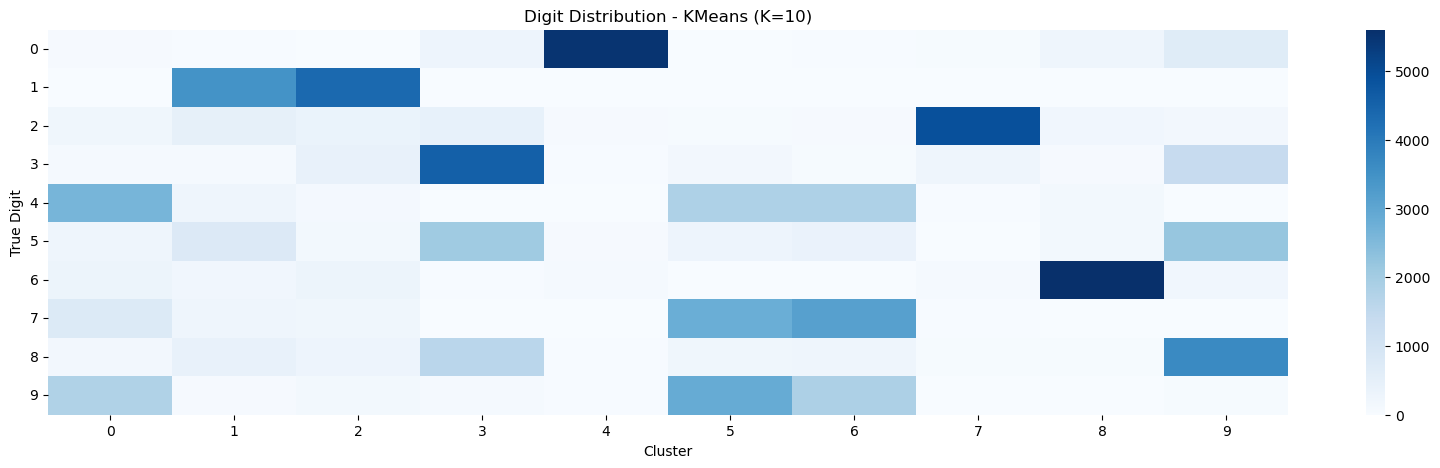

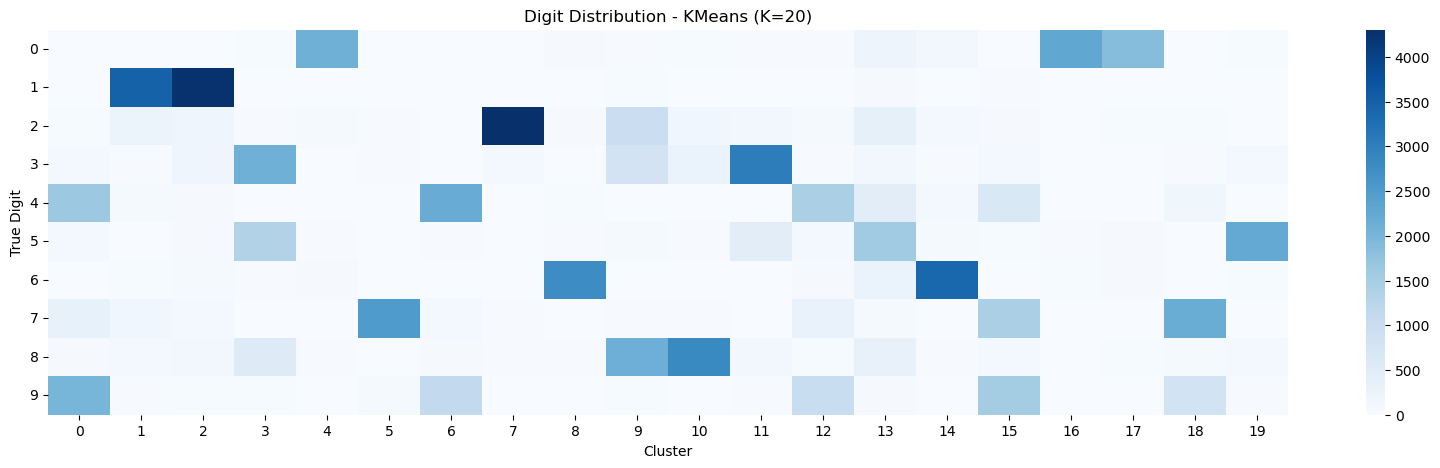

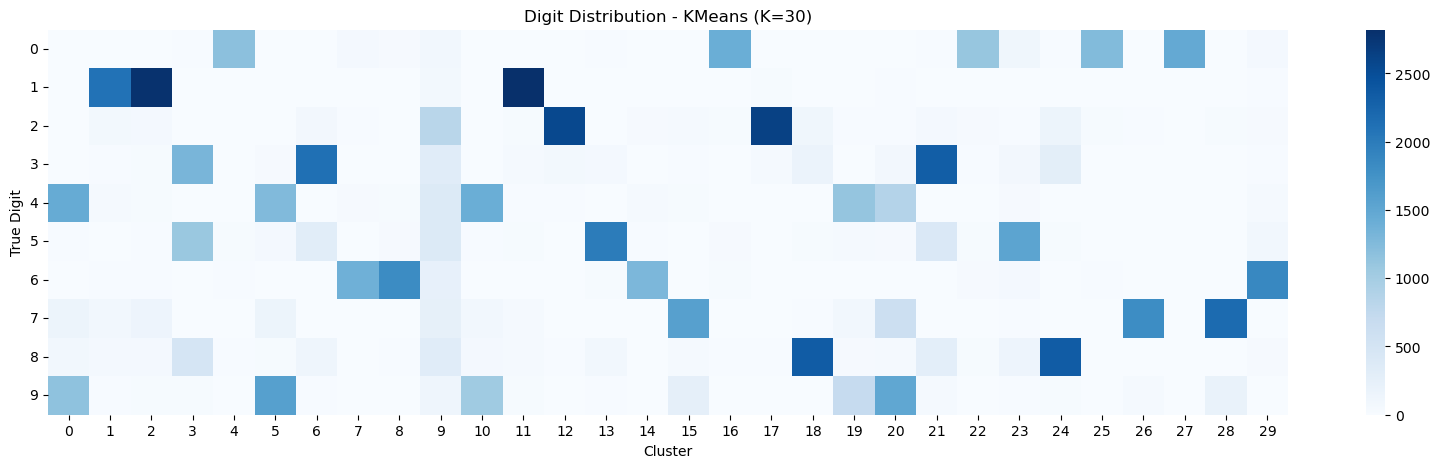

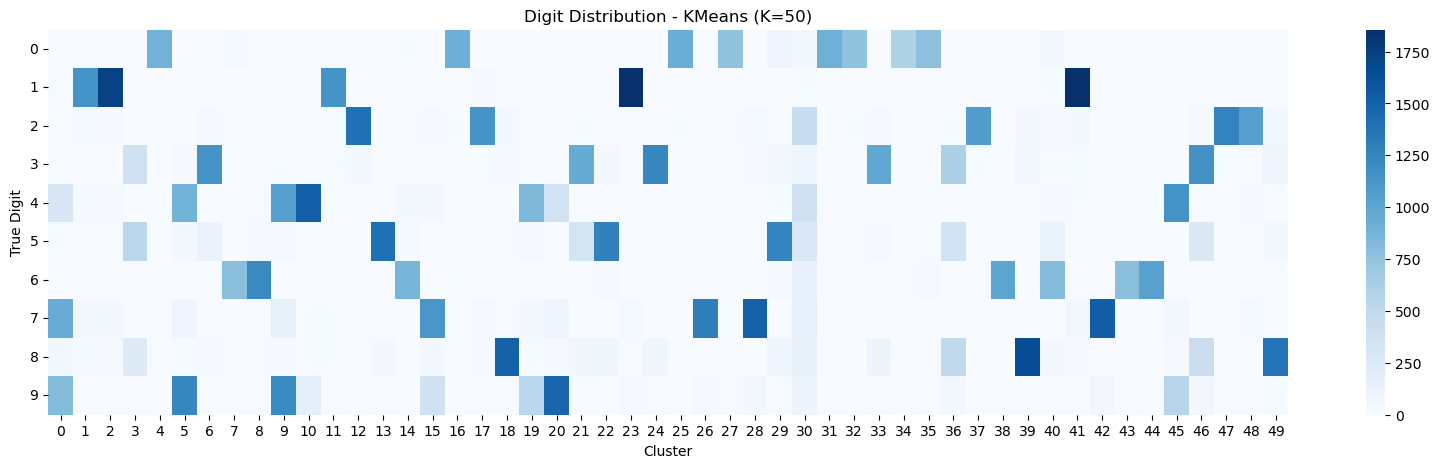

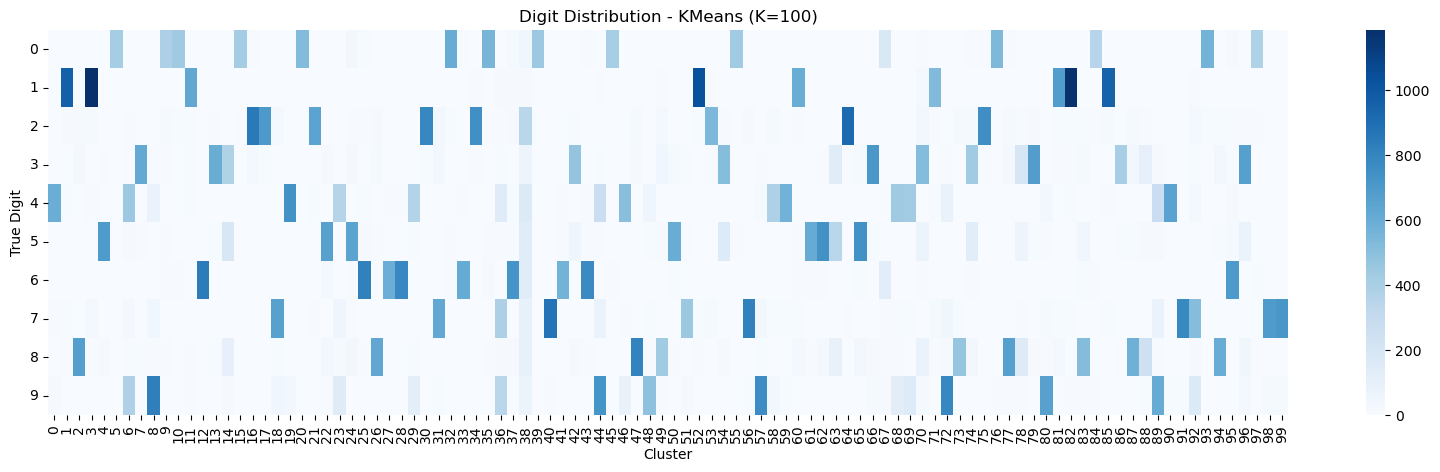

In [41]:
# Plot digit distribution across clusters for different K values
for K in kArray:
    plot_digit_cluster_distribution(results[K]["clusters"], y, K ,title=f"Digit Distribution - KMeans (K={K})")

We noticed that some digits that represented by 1-2 major clusters, tend to split by the change of K=10 and K=20 and etc..

we chose to examine digit 4 by its purity and average cluster images:


========== K = 10 ==========
Cluster 0 | size=6268 | purity=0.42


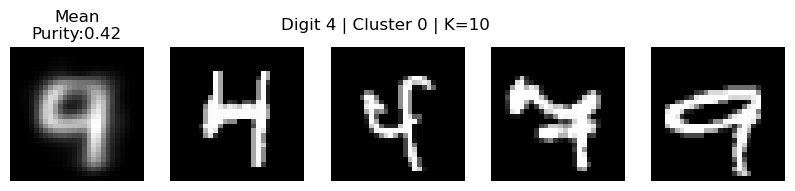


========== K = 20 ==========
Cluster 6 | size=3519 | purity=0.62


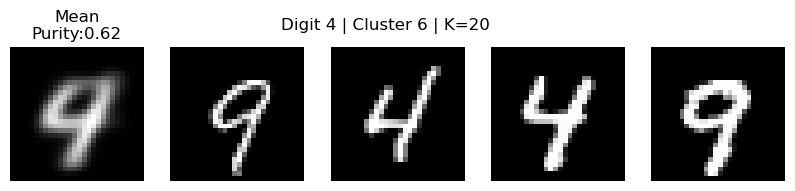

Cluster 12 | size=3060 | purity=0.47


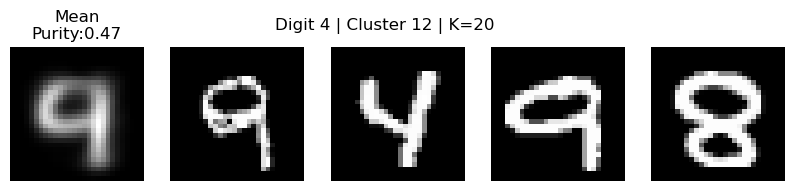


========== K = 30 ==========
Cluster 0 | size=2897 | purity=0.50


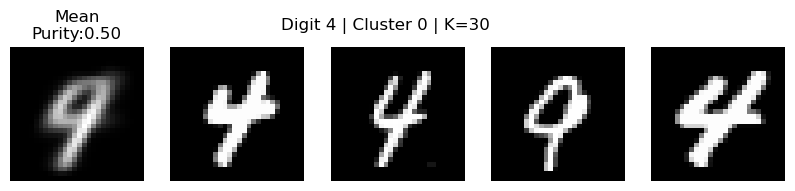

Cluster 5 | size=3146 | purity=0.40


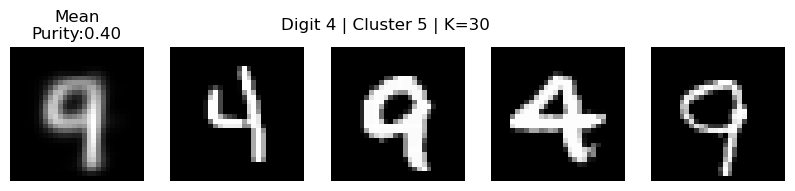

Cluster 10 | size=2639 | purity=0.54


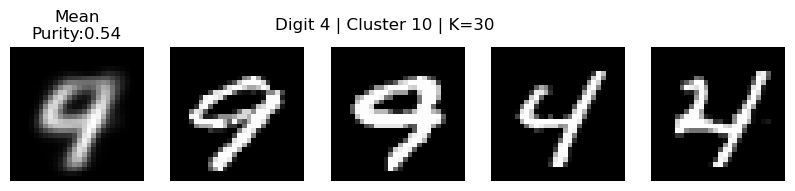

Cluster 19 | size=2037 | purity=0.55


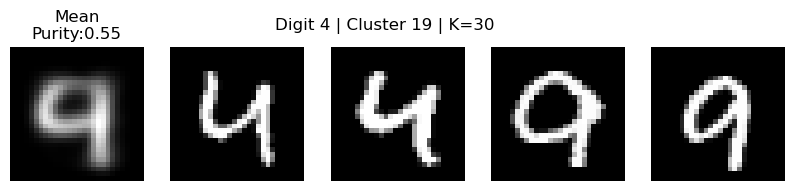


========== K = 50 ==========
Cluster 9 | size=2502 | purity=0.42


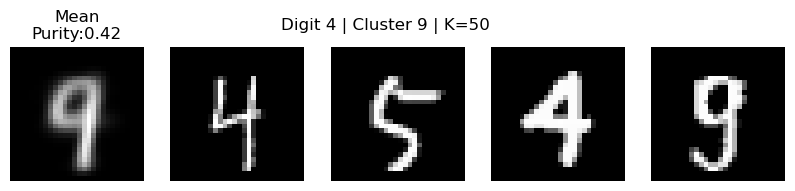

Cluster 10 | size=1746 | purity=0.87


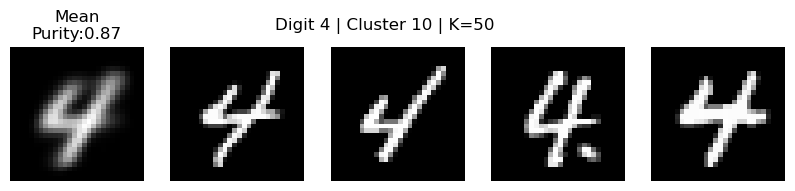

Cluster 19 | size=1479 | purity=0.57


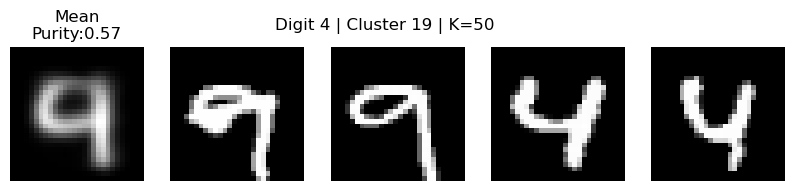

Cluster 45 | size=1794 | purity=0.64


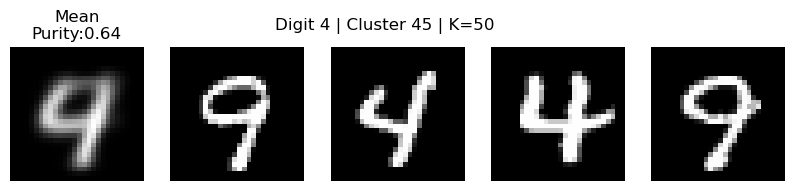


========== K = 100 ==========
Cluster 0 | size=623 | purity=0.96


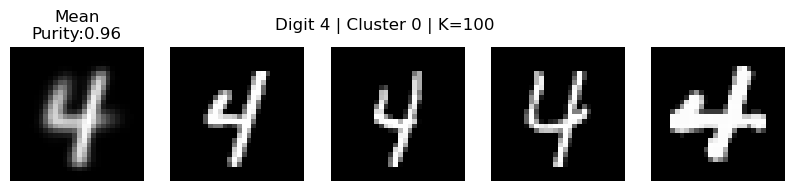

Cluster 6 | size=909 | purity=0.50


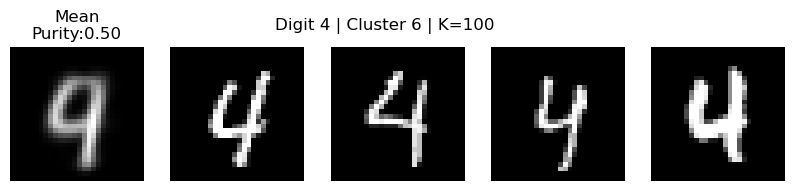

Cluster 19 | size=785 | purity=0.94


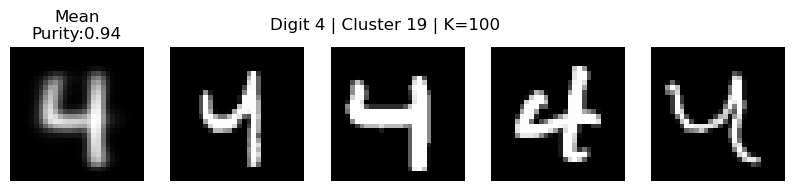

Cluster 23 | size=579 | purity=0.62


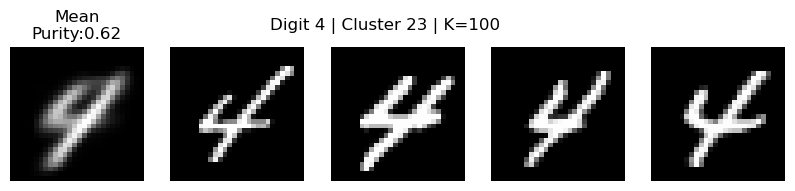

Cluster 29 | size=520 | purity=0.71


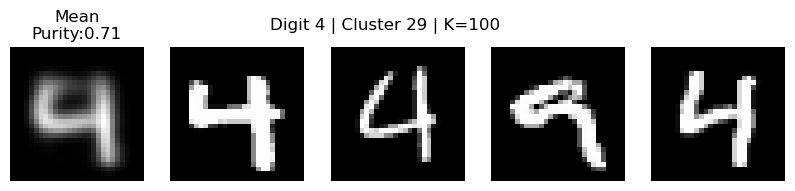

Cluster 46 | size=605 | purity=0.83


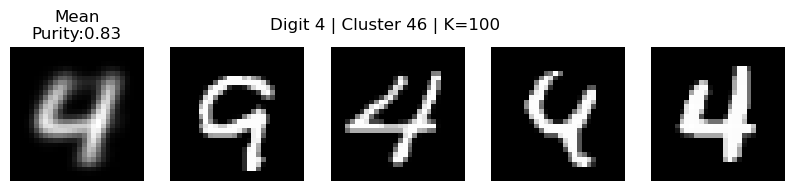

Cluster 58 | size=464 | purity=0.83


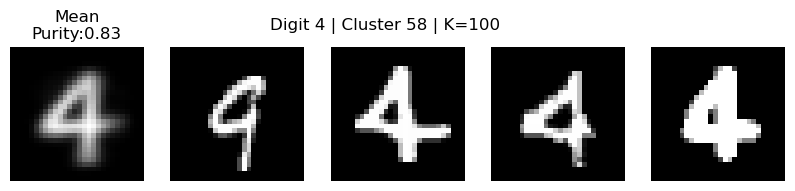

Cluster 59 | size=599 | purity=0.96


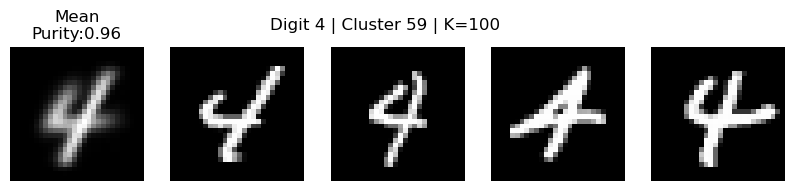

Cluster 68 | size=588 | purity=0.75


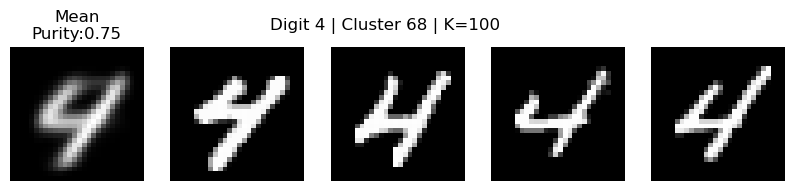

Cluster 69 | size=602 | purity=0.71


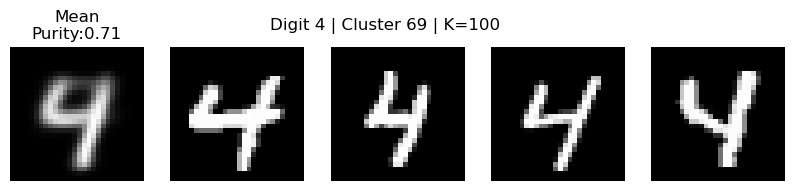

Cluster 90 | size=674 | purity=0.97


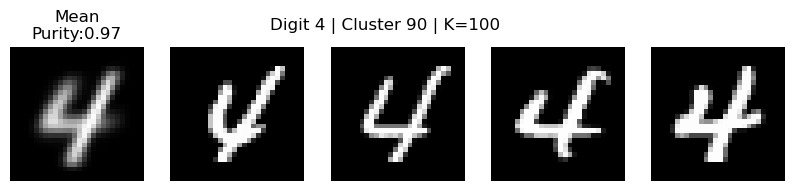

In [42]:
# Show cluster means and samples for clusters where digit 4 is dominant for different K values
inspect_digit_clusters(
    digit=4,
    results=results,
    X=X,
    y=y,
    Ks=kArray,
    samples_per_cluster=4,
    dominance_threshold=0.4
)

Examining digit 4, K = 10–50 yields low purity due to overlap with digit 9. Increasing to K = 100 produces some higher purity clusters that better isolate specific variants of digit 4 like a crossed line 4, with cluster means that clearly looks alike the digit. This suggests that KMeans separates digits primarily based on geometric structure under euclidean distance rather than stylistic grouping.

**Next**, we'll check the size of the clusters:

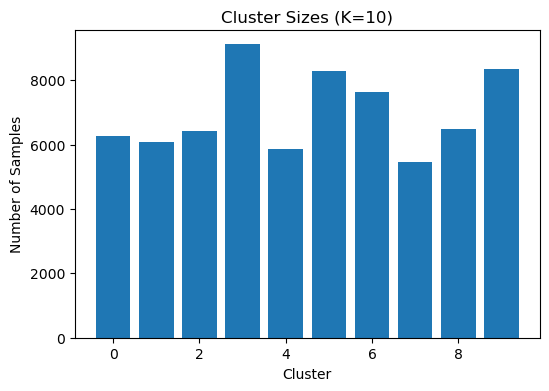

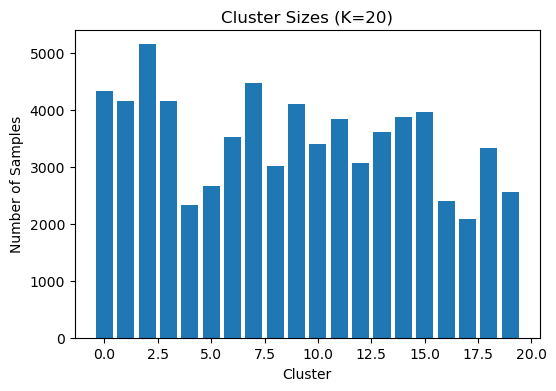

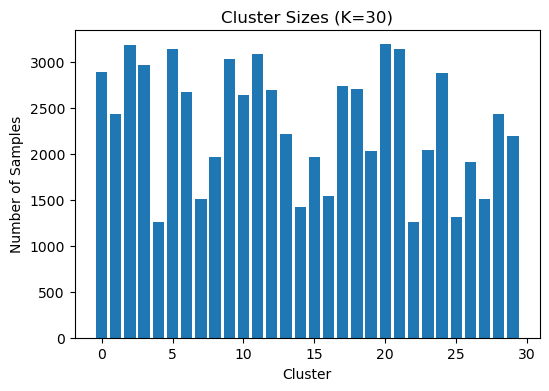

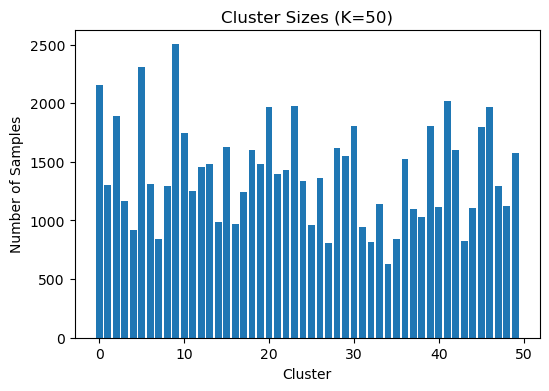

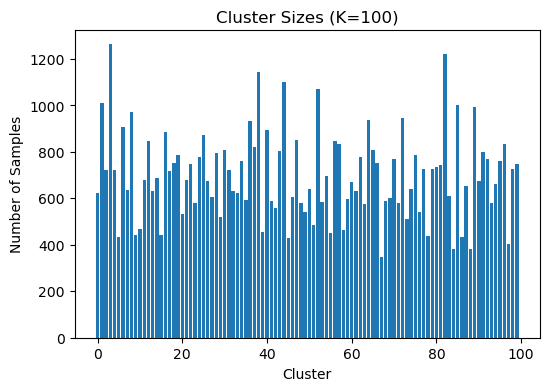

In [43]:
# Plot size of each cluster for different K values
plot_cluster_sizes(results[10]["clusters"], 10)
plot_cluster_sizes(results[20]["clusters"], 20)
plot_cluster_sizes(results[30]["clusters"], 30)
plot_cluster_sizes(results[50]["clusters"], 50)
plot_cluster_sizes(results[100]["clusters"], 100)

As K increases, cluster sizes decrease and the data is partitioned into finer regions. Since KMeans operates under Euclidean distance on raw pixel values, digits that are geometric similar in pixel space such as **`7 & 1`**, **`3 & 5 & 8`**,  **`closed top 4 & 9`** => tend to overlap. Because MNIST is not linearly separable in pixel space, these overlaps leads to cluster mixing and increasing K tends to isolate local geometric variations.